In [ ]:
import pandas as pd

# Load existing splits
train_df = pd.read_csv('processed_frames_single/train_processed.csv')
val_df = pd.read_csv('processed_frames_single/val_processed.csv')
test_df = pd.read_csv('processed_frames_single/test_processed.csv')

print(f"Current data:")
print(f"  Train: {len(train_df)} GIFs")
print(f"  Val:   {len(val_df)} GIFs")
print(f"  Test:  {len(test_df)} GIFs")
print(f"  Total: {len(train_df) + len(val_df) + len(test_df)} GIFs")

# Define 5-group emotion mapping
emotion_groups = {
    # Positive Energetic (~1,804 GIFs)
    'happiness': 'positive_energetic',
    'excitement': 'positive_energetic',
    'amusement': 'positive_energetic',
    
    # Positive Calm (~996 GIFs)
    'satisfaction': 'positive_calm',
    'contentment': 'positive_calm',
    'pleasure': 'positive_calm',
    'pride': 'positive_calm',
    
    # Negative Intense (~1,461 GIFs)
    'anger': 'negative_intense',
    'fear': 'negative_intense',
    'disgust': 'negative_intense',
    
    # Negative Subdued (~956 GIFs)
    'sadness': 'negative_subdued',
    'embarrassment': 'negative_subdued',
    
    # Unique categories
    'surprise': 'surprise',  # ~531 GIFs
    'contempt': 'contempt'   # ~176 GIFs
}

# Apply grouping
train_df['emotion_group'] = train_df['primary_emotion'].map(emotion_groups)
val_df['emotion_group'] = val_df['primary_emotion'].map(emotion_groups)
test_df['emotion_group'] = test_df['primary_emotion'].map(emotion_groups)

# Verify
print(f"\n{'='*60}")
print(f"EMOTION GROUP DISTRIBUTION")
print(f"{'='*60}")

print(f"\nTraining set:")
train_dist = train_df['emotion_group'].value_counts().sort_index()
print(train_dist)

print(f"\nValidation set:")
val_dist = val_df['emotion_group'].value_counts().sort_index()
print(val_dist)

print(f"\nTest set:")
test_dist = test_df['emotion_group'].value_counts().sort_index()
print(test_dist)

# Check for unmapped emotions
if train_df['emotion_group'].isna().any():
    print("\nWARNING: Some emotions not mapped!")
    print(train_df[train_df['emotion_group'].isna()]['primary_emotion'].unique())
else:
    print("\nAll emotions successfully mapped!")

# Save grouped datasets
train_df.to_csv('train_grouped.csv', index=False)
val_df.to_csv('val_grouped.csv', index=False)
test_df.to_csv('test_grouped.csv', index=False)

print(f"\n{'='*60}")
print(f"SAVED GROUPED DATASETS")
print(f"{'='*60}")
print(f"Files created:")
print(f"  - train_grouped.csv")
print(f"  - val_grouped.csv")
print(f"  - test_grouped.csv")

Current data:
  Train: 4145 GIFs
  Val:   889 GIFs
  Test:  889 GIFs
  Total: 5923 GIFs

EMOTION GROUP DISTRIBUTION

Training set:
emotion_group
contempt               123
negative_intense      1023
negative_subdued       684
positive_calm          681
positive_energetic    1262
surprise               372
Name: count, dtype: int64

Validation set:
emotion_group
contempt               27
negative_intense      219
negative_subdued      146
positive_calm         147
positive_energetic    271
surprise               79
Name: count, dtype: int64

Test set:
emotion_group
contempt               26
negative_intense      219
negative_subdued      147
positive_calm         146
positive_energetic    271
surprise               80
Name: count, dtype: int64

✅ All emotions successfully mapped!

✅ SAVED GROUPED DATASETS
Files created:
  - train_grouped.csv
  - val_grouped.csv
  - test_grouped.csv


In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

class GroupedEmotionDataset(Dataset):
    """Dataset for grouped emotion classification"""
    
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        
        # Create emotion group mapping
        self.emotion_groups = sorted(self.data['emotion_group'].unique())
        self.group2idx = {group: idx for idx, group in enumerate(self.emotion_groups)}
        self.idx2group = {idx: group for group, idx in self.group2idx.items()}
        
        print(f"✅ Loaded {len(self.data)} samples with {len(self.emotion_groups)} emotion groups")
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Load frame
        frame_path = row['frame_path']
        frame = Image.open(frame_path).convert('RGB')
        
        # Get label
        emotion_group = row['emotion_group']
        label = self.group2idx[emotion_group]
        
        # Apply transform
        if self.transform:
            frame = self.transform(frame)
        
        return frame, label

# Transforms with stronger augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = GroupedEmotionDataset('train_grouped.csv', transform=train_transform)
val_dataset = GroupedEmotionDataset('val_grouped.csv', transform=val_transform)
test_dataset = GroupedEmotionDataset('test_grouped.csv', transform=val_transform)

# Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n{'='*60}")
print(f"✅ DataLoaders Ready!")
print(f"{'='*60}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

print(f"\n📊 Emotion Group Mapping:")
for group, idx in sorted(train_dataset.group2idx.items(), key=lambda x: x[1]):
    count = len(train_dataset.data[train_dataset.data['emotion_group'] == group])
    print(f"  {idx}: {group:20s} ({count:4d} samples)")

✅ Loaded 4145 samples with 6 emotion groups
✅ Loaded 889 samples with 6 emotion groups
✅ Loaded 889 samples with 6 emotion groups

✅ DataLoaders Ready!
  Train batches: 130
  Val batches: 28
  Test batches: 28

📊 Emotion Group Mapping:
  0: contempt             ( 123 samples)
  1: negative_intense     (1023 samples)
  2: negative_subdued     ( 684 samples)
  3: positive_calm        ( 681 samples)
  4: positive_energetic   (1262 samples)
  5: surprise             ( 372 samples)


In [6]:
import torch.nn as nn
from torchvision import models

class GroupedEmotionClassifier(nn.Module):
    """ResNet-based classifier for 6 emotion groups"""
    
    def __init__(self, num_classes=6, pretrained=True):
        super(GroupedEmotionClassifier, self).__init__()
        
        # Load pretrained ResNet50
        resnet = models.resnet50(weights='IMAGENET1K_V1' if pretrained else None)
        
        # Remove final layer
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        
        # Custom classifier with dropout for regularization
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GroupedEmotionClassifier(num_classes=6, pretrained=True)
model = model.to(device)

print(f"\n{'='*60}")
print(f"✅ Model Created!")
print(f"{'='*60}")
print(f"  Device: {device}")
print(f"  Architecture: ResNet50 + Custom Classifier")
print(f"  Number of classes: 6")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")


✅ Model Created!
  Device: cpu
  Architecture: ResNet50 + Custom Classifier
  Number of classes: 6
  Total parameters: 24,561,222
  Trainable parameters: 24,561,222


In [7]:
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
emotion_labels = train_dataset.data['emotion_group'].map(train_dataset.group2idx).values
class_weights = compute_class_weight(
    'balanced',
    classes=np.arange(6),
    y=emotion_labels
)
class_weights = torch.FloatTensor(class_weights).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

print(f"\n{'='*60}")
print(f"✅ Training Setup Complete!")
print(f"{'='*60}")
print(f"  Loss: CrossEntropyLoss with class weights")
print(f"  Optimizer: Adam (lr=0.0001)")
print(f"  Scheduler: ReduceLROnPlateau")

print(f"\n📊 Class Weights:")
for group, idx in sorted(train_dataset.group2idx.items(), key=lambda x: class_weights[x[1]], reverse=True):
    print(f"  {group:20s}: {class_weights[idx]:.3f}")


✅ Training Setup Complete!
  Loss: CrossEntropyLoss with class weights
  Optimizer: Adam (lr=0.0001)
  Scheduler: ReduceLROnPlateau

📊 Class Weights:
  contempt            : 5.617
  surprise            : 1.857
  positive_calm       : 1.014
  negative_subdued    : 1.010
  negative_intense    : 0.675
  positive_energetic  : 0.547


In [8]:
from tqdm import tqdm

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({
            'loss': f'{running_loss/len(loader):.4f}',
            'acc': f'{100*correct/total:.2f}%'
        })
    
    return running_loss / len(loader), 100 * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return running_loss / len(loader), 100 * correct / total

print("✅ Training functions ready")

✅ Training functions ready


In [9]:
NUM_EPOCHS = 15
BEST_ACC = 0.0

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print(f"\n{'='*60}")
print(f"🚀 STARTING TRAINING - GROUPED EMOTIONS")
print(f"{'='*60}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Device: {device}")
print(f"  Classes: 6 emotion groups")
print(f"  Training samples: {len(train_dataset)}")
print(f"{'='*60}\n")

for epoch in range(NUM_EPOCHS):
    print(f"\n📍 Epoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    scheduler.step(val_acc)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    print(f"\n📊 Epoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    
    if val_acc > BEST_ACC:
        BEST_ACC = val_acc
        torch.save(model.state_dict(), 'best_model_grouped.pth')
        print(f"  ✅ New best model saved! (Val Acc: {val_acc:.2f}%)")

print(f"\n{'='*60}")
print(f"✅ TRAINING COMPLETE!")
print(f"{'='*60}")
print(f"  Best Validation Accuracy: {BEST_ACC:.2f}%")
print(f"  Model saved as: best_model_grouped.pth")


🚀 STARTING TRAINING - GROUPED EMOTIONS
  Epochs: 15
  Device: cpu
  Classes: 6 emotion groups
  Training samples: 4145


📍 Epoch 1/15
------------------------------------------------------------


Validation: 100%|██████████| 28/28 [01:30<00:00,  3.25s/it]



📊 Epoch 1 Summary:
  Train Loss: 1.9481 | Train Acc: 16.79%
  Val Loss:   1.8294 | Val Acc:   19.80%
  ✅ New best model saved! (Val Acc: 19.80%)

📍 Epoch 2/15
------------------------------------------------------------


Validation: 100%|██████████| 28/28 [01:15<00:00,  2.71s/it]



📊 Epoch 2 Summary:
  Train Loss: 1.8396 | Train Acc: 19.98%
  Val Loss:   1.8623 | Val Acc:   16.42%

📍 Epoch 3/15
------------------------------------------------------------


...


📊 Epoch 13 Summary:
  Train Loss: 0.8346 | Train Acc: 63.35%
  Val Loss:   2.6209 | Val Acc:   25.65%

📍 Epoch 14/15
------------------------------------------------------------


Validation: 100%|██████████| 28/28 [02:17<00:00,  4.89s/it]



📊 Epoch 14 Summary:
  Train Loss: 0.7142 | Train Acc: 68.15%
  Val Loss:   2.8751 | Val Acc:   24.18%

📍 Epoch 15/15
------------------------------------------------------------


Validation: 100%|██████████| 28/28 [02:18<00:00,  4.93s/it]



📊 Epoch 15 Summary:
  Train Loss: 0.6409 | Train Acc: 72.42%
  Val Loss:   2.8133 | Val Acc:   30.48%
  ✅ New best model saved! (Val Acc: 30.48%)

✅ TRAINING COMPLETE!
  Best Validation Accuracy: 30.48%
  Model saved as: best_model_grouped.pth


In [ ]:

# After training completes, 
def analyze_grouped_model():
    """Complete analysis of grouped emotion model"""
    
    # Load best model
    model.load_state_dict(torch.load('best_model_grouped.pth'))
    model.eval()
    
    # Test evaluation
    test_loss, test_acc = validate(model, test_loader, criterion, device)
    
    print(f"\n{'='*60}")
    print(f"📊 FINAL RESULTS - GROUPED EMOTIONS")
    print(f"{'='*60}")
    print(f"  Training Acc:   {history['train_acc'][-1]:.2f}%")
    print(f"  Validation Acc: {BEST_ACC:.2f}%")
    print(f"  Test Acc:       {test_acc:.2f}%")
    print(f"  Overfitting Gap: {history['train_acc'][-1] - test_acc:.2f}%")
    
    print(f"\n📈 Comparison with Previous Model:")
    print(f"  Old Val Acc: 21.15% → New Val Acc: {BEST_ACC:.2f}% (+{BEST_ACC-21.15:.2f}%)")
    print(f"  Old Test Acc: 23.40% → New Test Acc: {test_acc:.2f}% (+{test_acc-23.40:.2f}%)")
    print(f"  Old Overfitting: 61% → New Overfitting: {history['train_acc'][-1] - test_acc:.2f}%")
    
    # Get predictions for confusion matrix
    from sklearn.metrics import confusion_matrix, classification_report
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=train_dataset.emotion_groups,
                yticklabels=train_dataset.emotion_groups)
    plt.title('Confusion Matrix - Grouped Emotions (Test Set)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix_grouped.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Classification report
    print(f"\n{'='*60}")
    print("CLASSIFICATION REPORT")
    print(f"{'='*60}")
    print(classification_report(all_labels, all_preds,
                              target_names=train_dataset.emotion_groups,
                              zero_division=0))
    
    # Plot training curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    ax1.plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    ax1.plot(epochs, history['val_loss'], 'r-o', label='Val Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss - Grouped Emotions')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(epochs, history['train_acc'], 'b-o', label='Train Acc')
    ax2.plot(epochs, history['val_acc'], 'r-o', label='Val Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy - Grouped Emotions')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_curves_grouped.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return test_acc



Validation: 100%|██████████| 28/28 [02:21<00:00,  5.06s/it]



📊 FINAL RESULTS - GROUPED EMOTIONS
  Training Acc:   72.42%
  Validation Acc: 30.48%
  Test Acc:       35.88%
  Overfitting Gap: 36.54%

📈 Comparison with Previous Model:
  Old Val Acc: 21.15% → New Val Acc: 30.48% (+9.33%)
  Old Test Acc: 23.40% → New Test Acc: 35.88% (+12.48%)
  Old Overfitting: 61% → New Overfitting: 36.54%


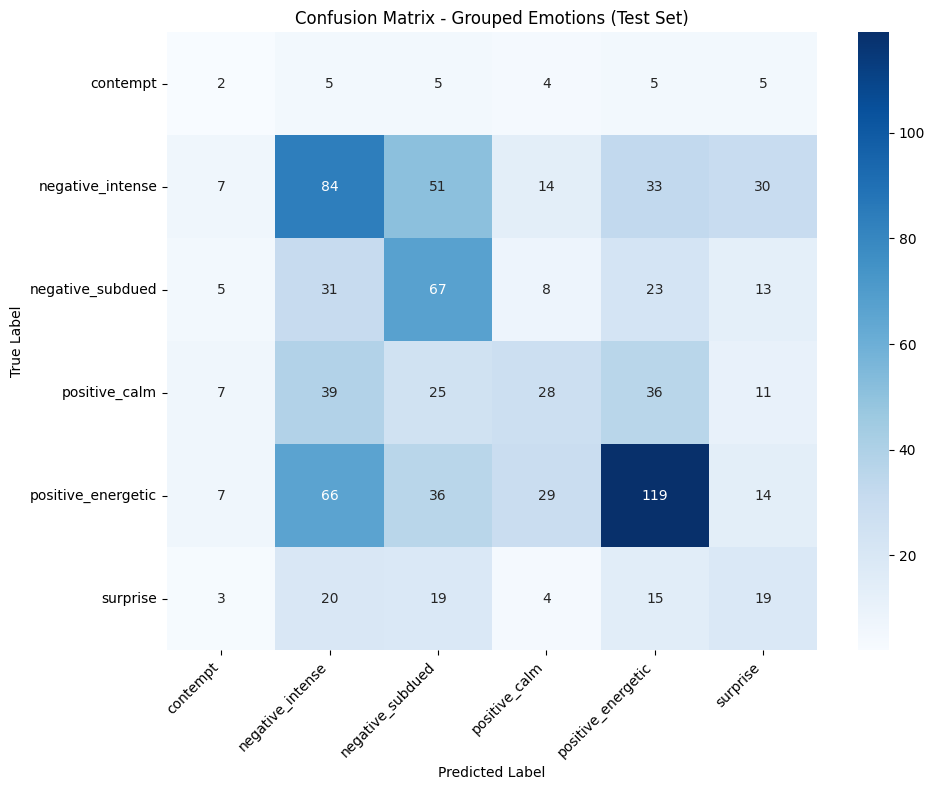


CLASSIFICATION REPORT
                    precision    recall  f1-score   support

          contempt       0.06      0.08      0.07        26
  negative_intense       0.34      0.38      0.36       219
  negative_subdued       0.33      0.46      0.38       147
     positive_calm       0.32      0.19      0.24       146
positive_energetic       0.52      0.44      0.47       271
          surprise       0.21      0.24      0.22        80

          accuracy                           0.36       889
         macro avg       0.30      0.30      0.29       889
      weighted avg       0.37      0.36      0.36       889



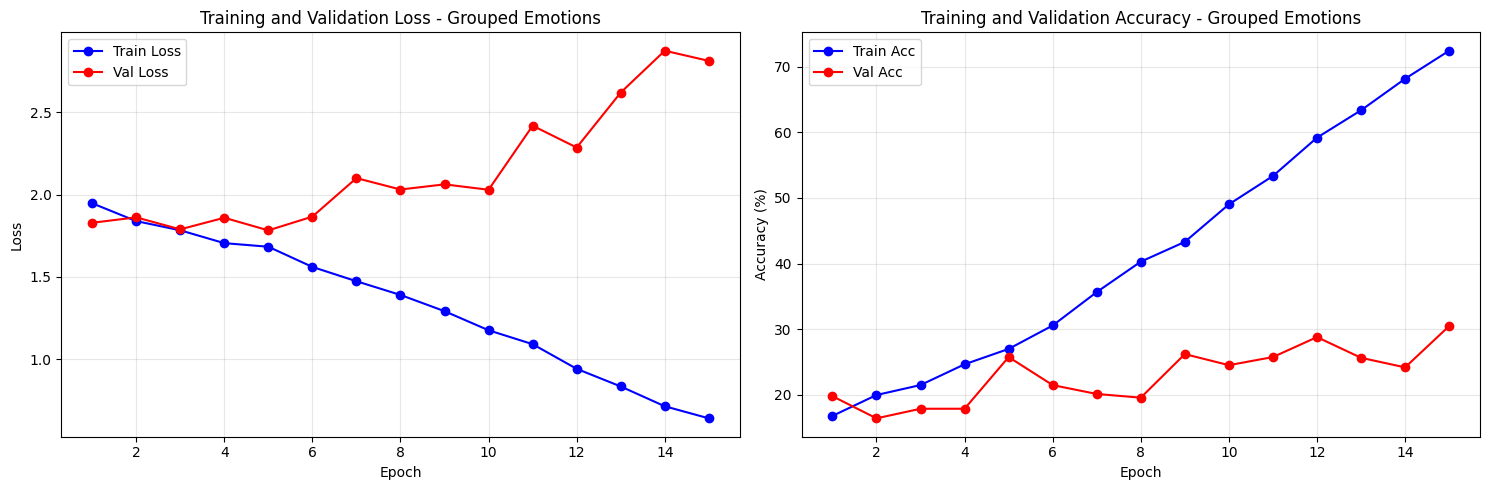

35.8830146231721

In [11]:
# Run the analysis
analyze_grouped_model()